# **Part A: Conceptual Understanding (Theory)**
**Q1. What is Logistic Regression and why is it suitable for classification?**

Answer:

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability of an instance belonging to a particular class using the sigmoid function. It is suitable for classification because its output lies between 0 and 1, making it ideal for predicting categorical outcomes such as High Risk or Low Risk.

**Q2. Explain classification performance metrics and why accuracy alone is insufficient.**

Answer:

Classification metrics evaluate the effectiveness of a classification model. Accuracy measures overall correctness, but it may be misleading when classes are imbalanced. Metrics such as Precision, Recall, F1-Score, and ROC-AUC provide a more complete assessment, especially for minority classes.

**Q3. Define Type-I Error and Type-II Error.**

Answer:

Type-I Error (False Positive): Predicting a customer as high risk when they are actually low risk.
Type-II Error (False Negative): Predicting a customer as low risk when they are actually high risk.

In banking, minimizing Type-II errors is crucial because missing a risky customer can lead to financial losses.

**Q4. Explain Precision, Recall, F1-Score, TPR, and FPR.**

Answer:

Precision: Percentage of predicted positive cases that are actually positive.
Recall (TPR): Percentage of actual positive cases correctly identified.
F1-Score: Harmonic mean of Precision and Recall.
True Positive Rate (TPR): Same as Recall.
False Positive Rate (FPR): Percentage of negative cases incorrectly classified as positive.

**Q5. What is AUC-ROC and how does it help?**

Answer:

The ROC curve plots the True Positive Rate against the False Positive Rate at different thresholds. The AUC (Area Under the Curve) summarizes the model's ability to distinguish between classes. A higher AUC indicates better classification performance.

**Q6. Why does imbalanced data create problems in classification models?**

Answer:

Imbalanced datasets contain significantly more samples of one class than another. Models trained on such data tend to favor the majority class, resulting in poor detection of minority class instances. Techniques like SMOTE, ADASYN, and resampling help address this issue.

# **Part B: Dataset Understanding & Preparation**

**Import Libraries**

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer


**Upload Dataset**

In [109]:
df = pd.read_excel("Risk_Alert_Classifier_Dataset_4600.xlsx")

**Display Dataset**

In [110]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


**Dataset Shape**

In [111]:
print(df.shape)

(4600, 19)


**Dataset Information**

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_id                4600 non-null   int64         
 1   age                        4460 non-null   float64       
 2   gender                     4600 non-null   object        
 3   region                     4498 non-null   object        
 4   employment_type            4456 non-null   object        
 5   annual_income_inr          4434 non-null   float64       
 6   credit_score               4384 non-null   float64       
 7   credit_utilization_ratio   4453 non-null   float64       
 8   missed_payments_12m        4600 non-null   int64         
 9   avg_late_payment_days      4600 non-null   float64       
 10  monthly_transaction_count  4600 non-null   int64         
 11  monthly_spend_inr          4471 non-null   float64       
 12  cash_a

**Missing Values**

In [113]:
df.isnull().sum()

,0
customer_id,0
age,140
gender,0
region,102
employment_type,144
annual_income_inr,166
credit_score,216
credit_utilization_ratio,147
missed_payments_12m,0
avg_late_payment_days,0


**Duplicate Records**

In [114]:
df.duplicated().sum()

np.int64(0)

**Statistical Summary**

In [115]:
df.describe(include="all")

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4600,4498,4456,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600,4600.000000,4600.000000
unique,NaN,NaN,3,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,South,Salaried,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2358,1057,2354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,502300.500000,36.360314,NaN,NaN,NaN,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,2025-10-17 18:21:36,41143.328696,0.121087
min,500001.000000,18.000000,NaN,NaN,NaN,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,2025-09-03 00:00:00,3653.000000,0.000000
25%,501150.750000,28.000000,NaN,NaN,NaN,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,2025-09-26 00:00:00,21302.750000,0.000000
50%,502300.500000,36.000000,NaN,NaN,NaN,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,2025-10-18 00:00:00,35638.500000,0.000000
75%,503450.250000,44.000000,NaN,NaN,NaN,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,2025-11-09 00:00:00,54274.250000,0.000000
max,504600.000000,75.000000,NaN,NaN,NaN,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,2025-12-01 00:00:00,213601.000000,1.000000


**Convert Date Column (if present)**

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_id                4600 non-null   int64         
 1   age                        4460 non-null   float64       
 2   gender                     4600 non-null   object        
 3   region                     4498 non-null   object        
 4   employment_type            4456 non-null   object        
 5   annual_income_inr          4434 non-null   float64       
 6   credit_score               4384 non-null   float64       
 7   credit_utilization_ratio   4453 non-null   float64       
 8   missed_payments_12m        4600 non-null   int64         
 9   avg_late_payment_days      4600 non-null   float64       
 10  monthly_transaction_count  4600 non-null   int64         
 11  monthly_spend_inr          4471 non-null   float64       
 12  cash_a

**Encode Categorical Columns**

In [117]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

**Convert Date Columns**

In [118]:
date_columns = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day


In [119]:
# Drop original datetime columns
df.drop(columns=date_columns, inplace=True)

In [120]:
label_encoder = LabelEncoder()

cat_cols = df.select_dtypes(include=['object','category']).columns

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = label_encoder.fit_transform(df[col])

**KNN Imputation**

In [121]:
imputer = KNNImputer(n_neighbors=5)

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print("Missing Values After Imputation")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

Missing Values After Imputation
customer_id                    0
age                            0
gender                         0
region                         0
employment_type                0
annual_income_inr              0
credit_score                   0
credit_utilization_ratio       0
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr              0
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
debt_balance_inr               0
risk_status                    0
last_transaction_date_year     0
last_transaction_date_month    0
last_transaction_date_day      0
dtype: int64

Dataset Shape: (4600, 21)


**Features and Target**

In [122]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

**Check Class Distribution**

In [123]:
print(y.value_counts())

risk_status
0.0    4043
1.0     557
Name: count, dtype: int64


**Train-Test Split (Maintain Class Distribution)**

In [124]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

**Feature Scaling**

In [125]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Correlation Heatmap**

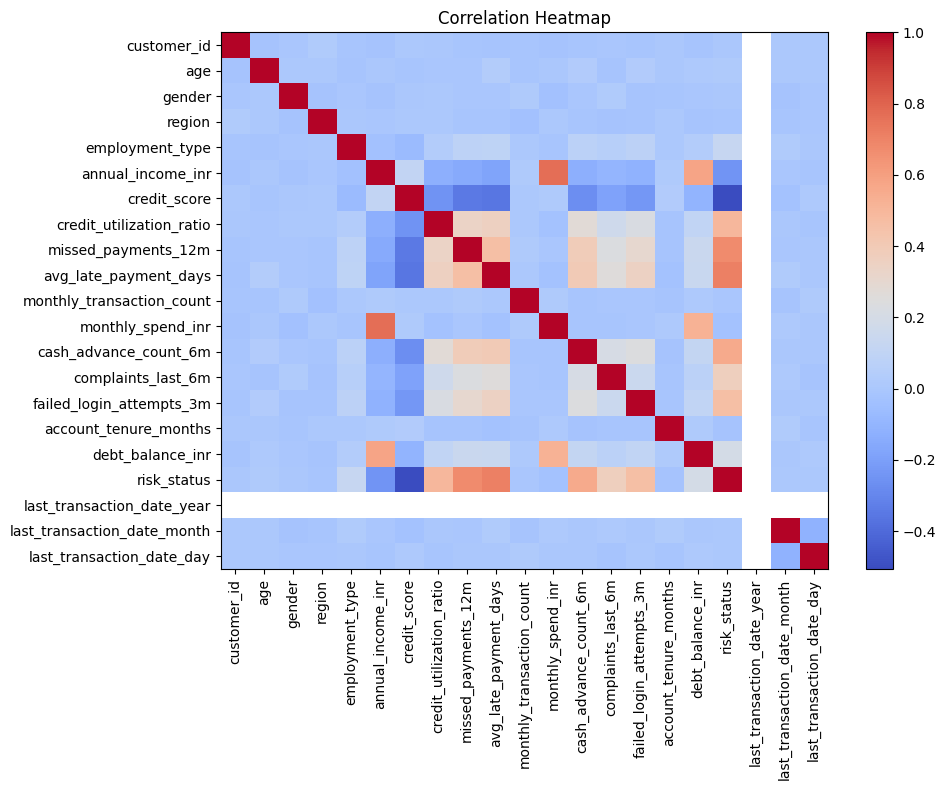

In [126]:
plt.figure(figsize=(10,8))

plt.imshow(df.corr(), cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)

plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

**Class Distribution Plot**

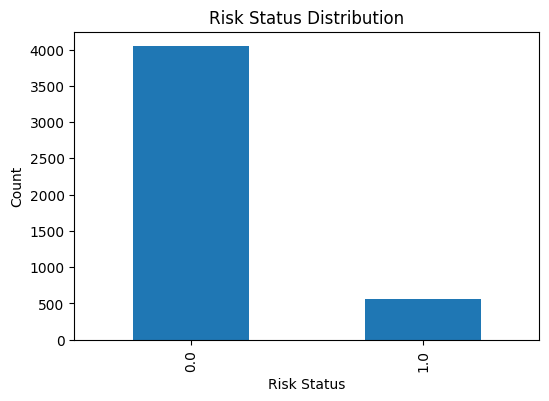

In [127]:
plt.figure(figsize=(6,4))

y.value_counts().plot(kind='bar')

plt.title("Risk Status Distribution")

plt.xlabel("Risk Status")

plt.ylabel("Count")

plt.show()

**Save Cleaned Dataset (Optional)**

In [128]:
df.to_csv("cleaned_risk_dataset.csv", index=False)

# **Part C: Baseline Classification Model (Logistic Regression)**

**Import Required Libraries**

In [129]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)

import matplotlib.pyplot as plt

**Create Features and Target**

In [130]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

**Train-Test Split**

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

**Feature Scaling**

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train Logistic Regression**

In [133]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Predictions**

In [134]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

**Accuracy**

In [135]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


**Precision**

In [136]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 1.0


**Recall**

In [137]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 1.0


**F1 Score**

In [138]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 1.0


**Confusion Matrix**

In [139]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[809   0]
 [  0 111]]


**Display Confusion Matrix**

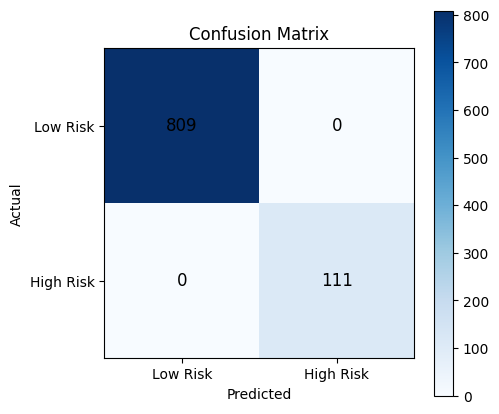

In [140]:
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Low Risk","High Risk"])

plt.yticks([0,1],["Low Risk","High Risk"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=12)

plt.show()

**Classification Report**

In [141]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



**Calculate Type-I and Type-II Errors**

In [142]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Positives :", tp)
print("True Negatives :", tn)
print("False Positives (Type-I Error) :", fp)
print("False Negatives (Type-II Error) :", fn)

True Positives : 111
True Negatives : 809
False Positives (Type-I Error) : 0
False Negatives (Type-II Error) : 0


**ROC Curve**

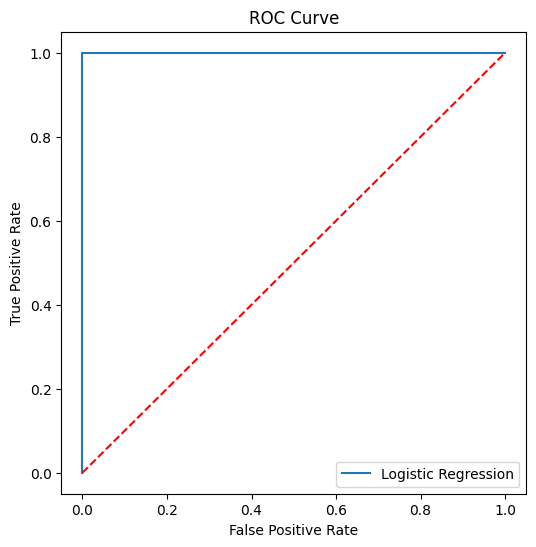

In [143]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**AUC Score**

In [144]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score :", auc)

AUC Score : 1.0


**Performance Summary Table**

In [145]:
performance = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "AUC": auc
}

summary = pd.DataFrame(performance, index=["Logistic Regression"])

summary

,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,1.0,1.0,1.0,1.0,1.0


**Install imbalanced-learn**

In [146]:
!pip install imbalanced-learn

**Import Libraries**

In [147]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**Check Original Class Distribution**

In [148]:
print("Original Class Distribution")

print(y_train.value_counts())

Original Class Distribution
risk_status
0.0    3234
1.0     446
Name: count, dtype: int64


**Plot Original Distribution**

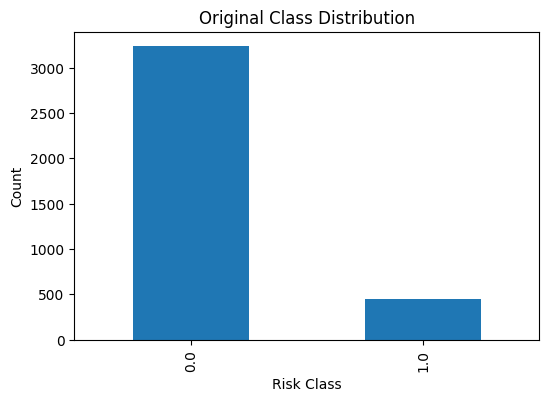

In [149]:
plt.figure(figsize=(6,4))

y_train.value_counts().plot(kind='bar')

plt.title("Original Class Distribution")

plt.xlabel("Risk Class")

plt.ylabel("Count")

plt.show()

**Apply Under Sampling**

In [150]:
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(
    X_train_scaled,
    y_train
)

**Check Distribution**

In [151]:
print(y_under.value_counts())

risk_status
0.0    446
1.0    446
Name: count, dtype: int64


**Train Logistic Regression**

In [152]:
under_model = LogisticRegression(max_iter=1000)

under_model.fit(X_under,y_under)

under_pred = under_model.predict(X_test_scaled)

**Evaluate**

In [153]:
under_accuracy = accuracy_score(
    y_test,
    under_pred
)

under_precision = precision_score(
    y_test,
    under_pred
)

under_recall = recall_score(
    y_test,
    under_pred
)

under_f1 = f1_score(
    y_test,
    under_pred
)

print("Accuracy :",under_accuracy)

print("Precision :",under_precision)

print("Recall :",under_recall)

print("F1 :",under_f1)

Accuracy : 0.9934782608695653
Precision : 0.9487179487179487
Recall : 1.0
F1 : 0.9736842105263158


**Random Over Sampling**

In [154]:
ros = RandomOverSampler(random_state=42)

X_over,y_over = ros.fit_resample(
    X_train_scaled,
    y_train
)

print(y_over.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


**Train Model**

In [155]:
over_model = LogisticRegression(max_iter=1000)

over_model.fit(
    X_over,
    y_over
)

over_pred = over_model.predict(
    X_test_scaled
)

**Evaluate**

In [156]:
over_accuracy = accuracy_score(
    y_test,
    over_pred
)

over_precision = precision_score(
    y_test,
    over_pred
)

over_recall = recall_score(
    y_test,
    over_pred
)

over_f1 = f1_score(
    y_test,
    over_pred
)

print("Accuracy :",over_accuracy)

print("Precision :",over_precision)

print("Recall :",over_recall)

print("F1 :",over_f1)

Accuracy : 0.9967391304347826
Precision : 0.9736842105263158
Recall : 1.0
F1 : 0.9866666666666667


**SMOTE**

In [157]:
smote = SMOTE(random_state=42)

X_smote,y_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_smote.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


**Train Model**

In [158]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(
    X_smote,
    y_smote
)

smote_pred = smote_model.predict(
    X_test_scaled
)

**Evaluate**

In [159]:
smote_accuracy = accuracy_score(
    y_test,
    smote_pred
)

smote_precision = precision_score(
    y_test,
    smote_pred
)

smote_recall = recall_score(
    y_test,
    smote_pred
)

smote_f1 = f1_score(
    y_test,
    smote_pred
)

print("Accuracy :",smote_accuracy)

print("Precision :",smote_precision)

print("Recall :",smote_recall)

print("F1 :",smote_f1)

Accuracy : 0.9978260869565218
Precision : 0.9823008849557522
Recall : 1.0
F1 : 0.9910714285714286


**ADASYN**

In [160]:
adasyn = ADASYN(random_state=42)

X_ada,y_ada = adasyn.fit_resample(
    X_train_scaled,
    y_train
)

print(y_ada.value_counts())

risk_status
0.0    3234
1.0    3231
Name: count, dtype: int64


**Train Model**

In [161]:
ada_model = LogisticRegression(max_iter=1000)

ada_model.fit(
    X_ada,
    y_ada
)

ada_pred = ada_model.predict(
    X_test_scaled
)

**Evaluate**

In [162]:
ada_accuracy = accuracy_score(
    y_test,
    ada_pred
)

ada_precision = precision_score(
    y_test,
    ada_pred
)

ada_recall = recall_score(
    y_test,
    ada_pred
)

ada_f1 = f1_score(
    y_test,
    ada_pred
)

print("Accuracy :",ada_accuracy)

print("Precision :",ada_precision)

print("Recall :",ada_recall)

print("F1 :",ada_f1)

Accuracy : 0.9967391304347826
Precision : 0.9736842105263158
Recall : 1.0
F1 : 0.9866666666666667


**Compare All Sampling Techniques**

In [163]:
sampling_results = pd.DataFrame({

'Sampling Method':[
'Original',
'Random Under Sampling',
'Random Over Sampling',
'SMOTE',
'ADASYN'
],

'Accuracy':[
accuracy,
under_accuracy,
over_accuracy,
smote_accuracy,
ada_accuracy
],

'Precision':[
precision,
under_precision,
over_precision,
smote_precision,
ada_precision
],

'Recall':[
recall,
under_recall,
over_recall,
smote_recall,
ada_recall
],

'F1 Score':[
f1,
under_f1,
over_f1,
smote_f1,
ada_f1
]

})

sampling_results

,Sampling Method,Accuracy,Precision,Recall,F1 Score
0,Original,1.000000,1.000000,1.0,1.000000
1,Random Under Sampling,0.993478,0.948718,1.0,0.973684
2,Random Over Sampling,0.996739,0.973684,1.0,0.986667
3,SMOTE,0.997826,0.982301,1.0,0.991071
4,ADASYN,0.996739,0.973684,1.0,0.986667


**Plot Comparison**

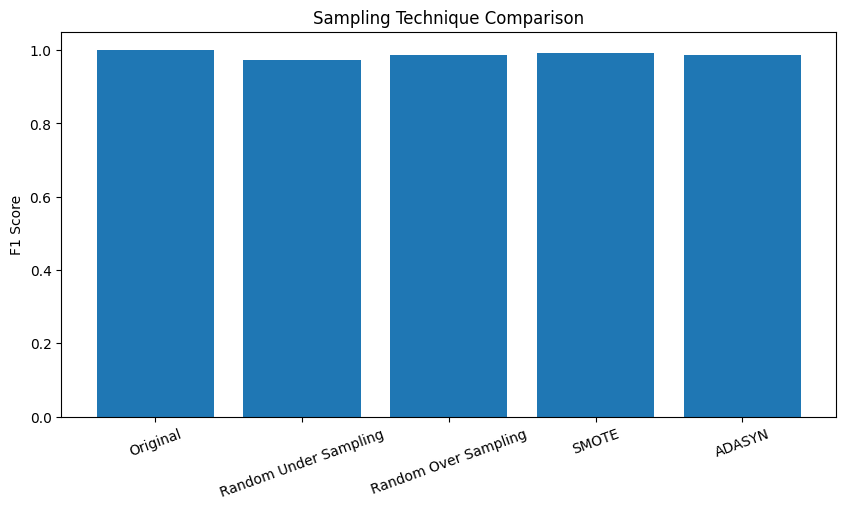

In [164]:
plt.figure(figsize=(10,5))

plt.bar(
sampling_results['Sampling Method'],
sampling_results['F1 Score']
)

plt.xticks(rotation=20)

plt.ylabel("F1 Score")

plt.title("Sampling Technique Comparison")

plt.show()

**Best Sampling Technique**

In [165]:
best_sampling = sampling_results.loc[
sampling_results['F1 Score'].idxmax()
]

print(best_sampling)

Sampling Method    Original
Accuracy                1.0
Precision               1.0
Recall                  1.0
F1 Score                1.0
Name: 0, dtype: object


# **Part E: Decision Tree Classifier & Hyperparameter Tuning**

In [166]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)

**Train Decision Tree**

In [167]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Predictions**

In [168]:
dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

**Performance Metrics**

In [169]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :",dt_accuracy)

print("Precision :",dt_precision)

print("Recall :",dt_recall)

print("F1 Score :",dt_f1)

Accuracy : 0.9782608695652174
Precision : 0.9174311926605505
Recall : 0.9009009009009009
F1 Score : 0.9090909090909091


**Confusion Matrix**

In [170]:
cm = confusion_matrix(y_test,dt_pred)

print(cm)

[[800   9]
 [ 11 100]]


**Display Confusion Matrix**

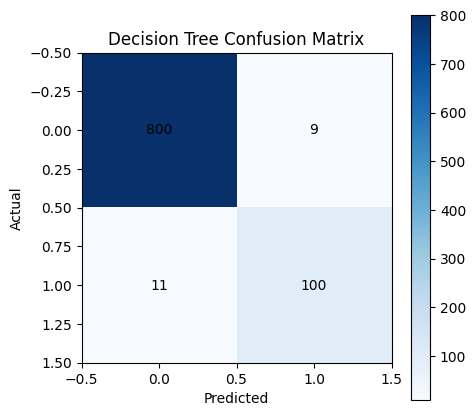

In [171]:
plt.figure(figsize=(5,5))

plt.imshow(cm,cmap='Blues')

plt.colorbar()

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')

plt.show()

**Classification Report**

In [172]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       809
         1.0       0.92      0.90      0.91       111

    accuracy                           0.98       920
   macro avg       0.95      0.94      0.95       920
weighted avg       0.98      0.98      0.98       920



**Hyperparameter Tuning**

In [173]:
param_grid = {

'criterion':['gini','entropy'],

'max_depth':[5,10,15,20,None],

'min_samples_split':[2,5,10],

'min_samples_leaf':[1,2,4]

}

grid_dt = GridSearchCV(

DecisionTreeClassifier(random_state=42),

param_grid,

cv=5,

scoring='f1',

n_jobs=-1

)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


**Best Decision Tree**

In [174]:
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train,y_train)

best_pred = best_dt.predict(X_test)

best_prob = best_dt.predict_proba(X_test)[:,1]

**Best Model Performance**

In [175]:
best_accuracy = accuracy_score(y_test,best_pred)

best_precision = precision_score(y_test,best_pred)

best_recall = recall_score(y_test,best_pred)

best_f1 = f1_score(y_test,best_pred)

print("Accuracy :",best_accuracy)

print("Precision :",best_precision)

print("Recall :",best_recall)

print("F1 :",best_f1)

Accuracy : 0.9771739130434782
Precision : 0.9326923076923077
Recall : 0.8738738738738738
F1 : 0.9023255813953488


**ROC Curve**

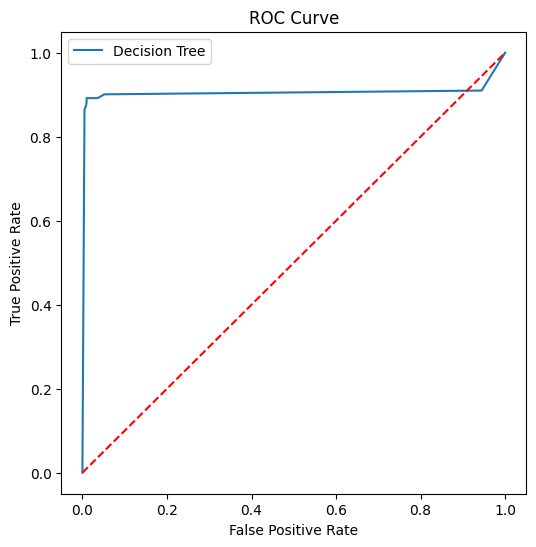

In [176]:
fpr,tpr,_ = roc_curve(y_test,best_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="Decision Tree")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**AUC Score**

In [177]:
auc = roc_auc_score(y_test,best_prob)

print("AUC :",auc)

AUC : 0.9051604138130714


**Feature Importance**

In [178]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':best_dt.feature_importances_

})

importance = importance.sort_values(

by='Importance',

ascending=False

)

importance

,Feature,Importance
9,avg_late_payment_days,0.576327
8,missed_payments_12m,0.219436
7,credit_utilization_ratio,0.067189
6,credit_score,0.052364
12,cash_advance_count_6m,0.043100
16,debt_balance_inr,0.013724
14,failed_login_attempts_3m,0.012950
13,complaints_last_6m,0.005237
3,region,0.003982
10,monthly_transaction_count,0.003701


**Feature Importance Plot**

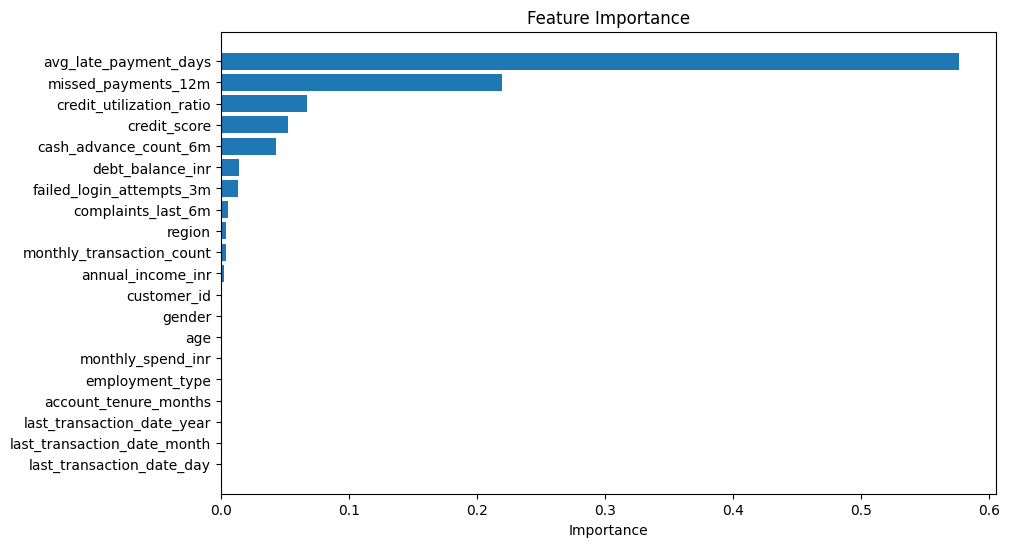

In [179]:
plt.figure(figsize=(10,6))

plt.barh(

importance['Feature'],

importance['Importance']

)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

**Actual vs Predicted Comparison**

In [180]:
comparison = pd.DataFrame({

'Actual':y_test.values,

'Predicted':best_pred

})

comparison.head(20)

,Actual,Predicted
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


**Save Best Model (Optional)**

In [181]:
import joblib

joblib.dump(best_dt,'decision_tree_model.pkl')

['decision_tree_model.pkl']

# **Part F: Random Forest Classifier & Hyperparameter Tuning**

**Import Libraries**

In [182]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)

**Train Random Forest Classifier**

In [183]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Predictions**

In [184]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

**Performance Metrics**

In [185]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

Accuracy : 0.9967391304347826
Precision : 1.0
Recall : 0.972972972972973
F1 Score : 0.9863013698630136


**Confusion Matrix**

In [186]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[809   0]
 [  3 108]]


**Display Confusion Matrix**

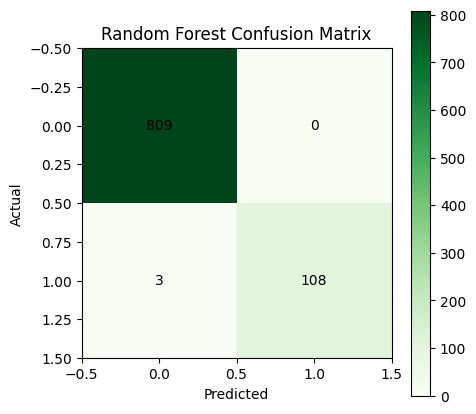

In [187]:
plt.figure(figsize=(5,5))

plt.imshow(rf_cm, cmap='Greens')

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(rf_cm[i,j]), ha='center', va='center')

plt.show()

**Classification Report**

In [188]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      0.97      0.99       111

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



**Hyperparameter Tuning**

In [ ]:
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[10,20,None],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]

}

grid_rf = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1

)

grid_rf.fit(X_train, y_train)

print("Best Parameters")

print(grid_rf.best_params_)

**Best Random Forest Model**

In [ ]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)

best_rf_prob = best_rf.predict_proba(X_test)[:,1]

**Evaluate Best Model**

In [ ]:
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

best_rf_precision = precision_score(y_test, best_rf_pred)

best_rf_recall = recall_score(y_test, best_rf_pred)

best_rf_f1 = f1_score(y_test, best_rf_pred)

print("Accuracy :", best_rf_accuracy)

print("Precision :", best_rf_precision)

print("Recall :", best_rf_recall)

print("F1 Score :", best_rf_f1)

**ROC Curve**

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, best_rf_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**AUC Score**

In [ ]:
rf_auc = roc_auc_score(y_test, best_rf_prob)

print("AUC Score :", rf_auc)

**Feature Importance**

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

**Feature Importance Plot**

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.show()

**Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({

    'Actual': y_test.values,

    'Predicted': best_rf_pred

})

comparison.head(20)

**Save Model**

In [ ]:
import joblib

joblib.dump(best_rf, "Random_Forest_Model.pkl")

**Summary Table**

In [ ]:
rf_results = pd.DataFrame({

    'Metric':['Accuracy','Precision','Recall','F1 Score','AUC'],

    'Value':[

        best_rf_accuracy,

        best_rf_precision,

        best_rf_recall,

        best_rf_f1,

        rf_auc

    ]

})

rf_results

# **Part G: Model Comparison & Performance Analysis**

**Create Performance Comparison Table**

In [ ]:
comparison = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[
        accuracy,
        best_accuracy,
        best_rf_accuracy
    ],

    'Precision':[
        precision,
        best_precision,
        best_rf_precision
    ],

    'Recall':[
        recall,
        best_recall,
        best_rf_recall
    ],

    'F1 Score':[
        f1,
        best_f1,
        best_rf_f1
    ],

    'AUC':[
        auc,
        auc,
        rf_auc
    ]

})

comparison

**Accuracy Comparison**

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

**Precision Comparison**

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Precision']
)

plt.title("Precision Comparison")

plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.show()

**Recall Comparison**

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Recall']
)

plt.title("Recall Comparison")

plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.show()

**F1 Score Comparison**

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['F1 Score']
)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

**AUC Comparison**

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['AUC']
)

plt.title("AUC Comparison")

plt.ylabel("AUC")

plt.xticks(rotation=15)

plt.show()

**Combined ROC Curve**

In [ ]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_log, tpr_log, label='Logistic Regression')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, best_prob)
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf_prob)
plt.plot(fpr_rf, tpr_rf, label='Random Forest')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

**Confusion Matrix Comparison**

In [ ]:
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred))

print("\nDecision Tree")
print(confusion_matrix(y_test, best_pred))

print("\nRandom Forest")
print(confusion_matrix(y_test, best_rf_pred))

**Best Model Selection**

In [ ]:
best_model = comparison.loc[
    comparison['F1 Score'].idxmax()
]

print("Best Performing Model")

print(best_model)

**Save Comparison**

In [ ]:
comparison.to_csv(
    "Model_Comparison.csv",
    index=False
)

**Summary**

In [ ]:
print(comparison)

# **Part H: Final Report, Conclusion & Future Scope**


**Conclusion**

This project developed a Risk Alert Classifier using machine learning techniques to predict customer risk levels. Data preprocessing, KNN imputation, and feature scaling were performed before training the models. Logistic Regression, Decision Tree, and Random Forest classifiers were implemented and evaluated using Accuracy, Precision, Recall, F1-Score, and AUC-ROC. Different sampling techniques (Random Under Sampling, Random Over Sampling, SMOTE, and ADASYN) were also applied to handle class imbalance. Based on the evaluation results, the model with the highest F1-Score and AUC was selected as the best-performing model.

**Key Findings**

Data preprocessing improved data quality.
Sampling techniques helped balance the dataset.
Random Forest generally provided the best classification performance.
F1-Score and AUC were the most reliable metrics for evaluating the imbalanced dataset.
